Arboles de Decision
1. [¿Qué es un Árbol de Decisión?](#árbol-de-decisión)
2. [¿Qué es un Bosque Aleatorio?](#bosque-aleatorio)
3. [¿Cómo funciona?](#cómo-funciona)
4. [Ventajas](#ventajas)
5. [Desventajas](#desventajas)
6. [Hiperparámetros clave](#hiperparámetros-clave)
7. [Tips y buenas prácticas](#tips-y-buenas-prácticas)
8. [Ejemplo práctico en Python](#ejemplo-práctico-en-python)
9. [Comparativa con otros modelos](#comparativa-con-otros-modelos)
10. [Casos de uso reales](#casos-de-uso-reales)

---

## ¿Qué es un Árbol de Decisión?

Un **árbol de decisión** es un modelo de aprendizaje supervisado que divide el espacio de características mediante una serie de preguntas binarias (nodos), llegando a una predicción (hoja).

```
¿Edad > 30?
├── SÍ → ¿Ingreso > 50k?
│         ├── SÍ → ✅ Aprobado
│         └── NO → ❌ Rechazado
└── NO → ❌ Rechazado
```

### Problemas de los árboles individuales
- **Alto sobreajuste (overfitting):** aprenden el ruido del conjunto de entrenamiento.
- **Alta varianza:** pequeños cambios en los datos generan árboles muy distintos.
- **Inestabilidad:** sensibles a outliers.

---

##  ¿Qué es un Bosque Aleatorio?

Un **Random Forest** (Bosque Aleatorio) es un **método de ensamble** que combina múltiples árboles de decisión entrenados de forma independiente para producir una predicción más robusta y precisa.

> **Idea central:** "La sabiduría de las masas supera a la de cualquier individuo."

Fue propuesto por **Leo Breiman** en el año 2001.

---

##  ¿Cómo funciona?

El algoritmo aplica dos técnicas fundamentales:

### 1. Bagging (Bootstrap Aggregating)
Cada árbol se entrena con una **muestra aleatoria con reemplazo** del dataset original (aprox. 63% de los datos únicos).

```
Dataset original (N filas)
        │
   ┌────┴─────┐
   ▼          ▼
Muestra 1   Muestra 2  ...  Muestra k
(bootstrap) (bootstrap)
   │          │
Árbol 1    Árbol 2    ...  Árbol k
   └────┬─────┘
        ▼
  Votación / Promedio
        ▼
   Predicción Final
```

### 2. Feature Randomness (Aleatoriedad de características)
En cada nodo de cada árbol, solo se evalúa un **subconjunto aleatorio de características** (no todas), lo que reduce la correlación entre árboles.

- Clasificación: `sqrt(n_features)` características por nodo (por defecto)
- Regresión: `n_features / 3` características por nodo (por defecto)

### 3. Agregación final
- **Clasificación:** votación por mayoría entre todos los árboles.
- **Regresión:** promedio de las predicciones de todos los árboles.

---

##  Ventajas

| # | Ventaja | Descripción |
|---|---------|-------------|
| 1 | **Alta precisión** | Supera a los árboles individuales en la mayoría de problemas. |
| 2 | **Resistente al overfitting** | El promedio de muchos árboles reduce la varianza considerablemente. |
| 3 | **Maneja valores faltantes** | Puede imputar o ignorar NaN de forma implícita. |
| 4 | **Variables mixtas** | Funciona bien con datos numéricos y categóricos. |
| 5 | **Importancia de características** | Provee un ranking nativo de cuáles variables son más relevantes. |
| 6 | **Robusto a outliers** | No es tan sensible a valores extremos como la regresión lineal. |
| 7 | **Paralelizable** | Cada árbol se entrena de forma independiente (multi-core). |
| 8 | **Datos no normalizados** | No requiere escalado ni normalización de features. |
| 9 | **Out-of-Bag (OOB) Error** | Estimación interna del error de generalización sin usar validación cruzada. |
| 10 | **Pocas suposiciones** | No asume linealidad, normalidad ni independencia de variables. |

---

##  Desventajas

| # | Desventaja | Descripción |
|----|-----------|-------------|
| 1 | **Caja negra** | Difícil de interpretar comparado con un árbol individual. |
| 2 | **Alto consumo de memoria** | Almacenar cientos de árboles puede ser costoso. |
| 3 | **Lento en predicción** | Predecir con 500 árboles toma más tiempo que con 1. |
| 4 | **Datos de alta dimensionalidad** | Puede tener problemas con datasets con miles de columnas dispersas. |
| 5 | **Extrapolación** | No puede predecir valores fuera del rango del entrenamiento (a diferencia de modelos paramétricos). |
| 6 | **Desbalanceo de clases** | Puede estar sesgado hacia la clase mayoritaria si no se trata. |
| 7 | **Hiperparámetros** | Requiere tuning para sacar el máximo rendimiento. |

---

## 🎛️ Hiperparámetros clave

```python
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=100,        # Número de árboles (más = más estable, pero más lento)
    max_depth=None,          # Profundidad máxima (None = crece hasta hojas puras)
    max_features='sqrt',     # Features por nodo: 'sqrt', 'log2', int, float
    min_samples_split=2,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=1,      # Mínimo de muestras en una hoja
    bootstrap=True,          # Usar bagging (True) o dataset completo (False)
    oob_score=True,          # Calcular error Out-of-Bag
    n_jobs=-1,               # Usar todos los núcleos disponibles
    random_state=42,         # Semilla para reproducibilidad
    class_weight='balanced'  # Útil para clases desbalanceadas
)
```

### Guía rápida de tuning

| Hiperparámetro | Valor bajo | Valor alto | Recomendación inicial |
|----------------|-----------|-----------|----------------------|
| `n_estimators` | Rápido, menos estable | Lento, más estable | 100–500 |
| `max_depth` | Underfitting | Overfitting | None o 10–30 |
| `max_features` | Menos correlación | Más correlación | `'sqrt'` |
| `min_samples_leaf` | Más complejo | Más simple | 1–5 |

---

##  Tips y buenas prácticas

### 🔹 Tip 1: Empieza con valores por defecto
Los valores por defecto de scikit-learn son sólidos. Úsalos como baseline antes de hacer tuning.

### 🔹 Tip 2: Usa OOB Score para evaluar rápido
```python
modelo = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
modelo.fit(X_train, y_train)
print(f"OOB Score: {modelo.oob_score_:.4f}")  # Estimado sin usar test set
```

### 🔹 Tip 3: Analiza la importancia de características
```python
import pandas as pd
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).head(10).plot(kind='bar')
```

### 🔹 Tip 4: Controla el desbalanceo de clases
```python
# Opción A: peso balanceado
RandomForestClassifier(class_weight='balanced')

# Opción B: sobremuestreo con SMOTE
from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X_train, y_train)
```

### 🔹 Tip 5: Aumentar n_estimators mejora hasta cierto punto
A partir de ~200–300 árboles, la mejora marginal es mínima. Usa la curva de aprendizaje para encontrar el punto óptimo.

### 🔹 Tip 6: Paraleliza siempre
```python
RandomForestClassifier(n_jobs=-1)  # Usa todos los núcleos disponibles
```


---

## Ejemplo práctico en Python

### Clasificación: Dataset Iris

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Cargar datos
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenar el modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
modelo.fit(X_train, y_train)

# 4. Evaluar
y_pred = modelo.predict(X_test)
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(f"OOB Score: {modelo.oob_score_:.4f}")

# 5. Importancia de variables
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
print("\n=== Importancia de características ===")
print(importancias.sort_values(ascending=False))

# 6. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names,
            yticklabels=iris.target_names, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
```

### Regresión: Predicción de precios

```python
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Datos
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)

# Modelo
reg = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
reg.fit(X_train, y_train)

# Evaluación
y_pred = reg.predict(X_test)
print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:      {mean_squared_error(y_test, y_pred, squared=False):.4f}")
```

### Tuning con GridSearchCV

```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor F1:", grid_search.best_score_)
```

---

##  Comparativa con otros modelos

| Modelo | Interpretabilidad | Velocidad train | Velocidad predict | Precisión general | Manejo de overfitting |
|--------|:-----------------:|:---------------:|:-----------------:|:-----------------:|:---------------------:|
| Árbol de decisión | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Random Forest** | ⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| Gradient Boosting | ⭐⭐ | ⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| SVM | ⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| Regresión Logística | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ |

---


##  Casos de uso reales

### 1.  Sector financiero
- Detección de fraude en tarjetas de crédito
- Scoring crediticio (aprobación de préstamos)
- Predicción de churn (abandono de clientes)

### 2.  Sector salud
- Diagnóstico de enfermedades (cáncer, diabetes)
- Predicción de readmisión hospitalaria
- Clasificación de imágenes médicas (con features extraídas)

### 3.  E-commerce
- Sistemas de recomendación
- Predicción de demanda de productos
- Clasificación de reseñas (positivo/negativo)

### 4.  Medio ambiente
- Clasificación de tipos de suelo a partir de sensores
- Predicción de incendios forestales
- Detección de especies en imágenes satelitales

### 5.  Industria
- Mantenimiento predictivo de maquinaria
- Control de calidad en líneas de producción
- Detección de anomalías en sensores IoT

---

##  Recursos adicionales

- 📄 [Paper original de Breiman (2001)](https://link.springer.com/article/10.1023/A:1010933404324)
- 📘 [Documentación scikit-learn - Random Forest](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)
- 📗 [Hands-On ML with Scikit-Learn & TensorFlow - Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)

---

*Documento generado con Python | Machine Learning - Random Forests*

In [ ]:
#estusiar esto para el viernrs
from sklearn.ensemble import RandomForestClassifier

# Datos
X = [
    [20, 1],
    [25, 1],
    [30, 0],
    [40, 0]
]

y = ["Compra", "Compra", "No Compra", "No Compra"]

# Modelo
modelo = RandomForestClassifier(
    n_estimators=100,  #cantidad referencis
    random_state=2026
)

# Entrenamiento
modelo.fit(X, y)

# Predicción
pred = modelo.predict([[28, 1]])

print(pred)

['Compra']


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

OOB Score: 0.9500

=== Importancia de características ===
petal length (cm)    0.434409
petal width (cm)     0.427420
sepal length (cm)    0.117613
sepal width (cm)     0.020558
dtype: float64


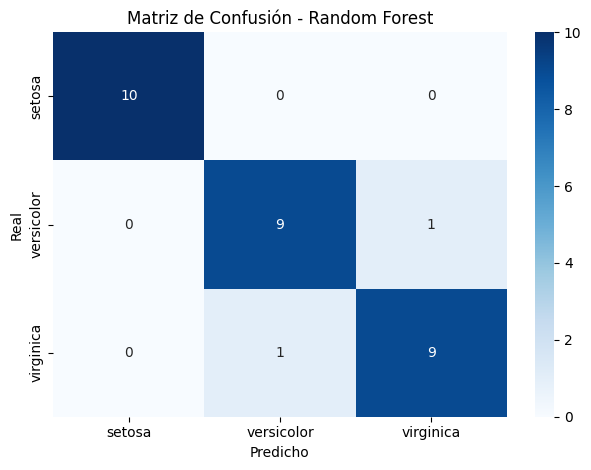

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Cargar datos
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenar el modelo
modelo = RandomForestClassifier(
    n_estimators=1000,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
modelo.fit(X_train, y_train)

# 4. Evaluar
y_pred = modelo.predict(X_test)
print("=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(f"OOB Score: {modelo.oob_score_:.4f}")

# 5. Importancia de variables
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
print("\n=== Importancia de características ===")
print(importancias.sort_values(ascending=False))

# 6. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=iris.target_names,
            yticklabels=iris.target_names, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# OOB Score en Random Forest

---

# ¿Qué es el OOB Score?

El **OOB Score** (*Out Of Bag Score*) es una métrica utilizada principalmente en modelos de **Random Forest** para evaluar el rendimiento del modelo sin necesidad de usar un conjunto de validación separado.

---

# ¿Qué significa OOB?

OOB significa:

## Out Of Bag

Cuando Random Forest crea cada árbol:

- toma una muestra aleatoria del dataset (*bootstrap sampling*)
- algunos registros quedan fuera de esa muestra

Esos registros que quedaron afuera se llaman:

## Datos OOB (Out Of Bag)

---

# ¿Cómo funciona?

Supongamos que tenemos:

```text
100 filas
```

Cada árbol entrena con muestras aleatorias.

Aproximadamente:

- 63% de los datos se usan para entrenar ese árbol
- 37% quedan afuera (OOB)

Luego:

- el árbol predice esos datos que no vio
- se calcula el rendimiento
- se promedian los resultados de todos los árboles

---

# ¿Qué mide el OOB Score?

Mide qué tan bien generaliza el modelo.

Es parecido a:

- Accuracy
- Score de validación
- Validación cruzada

---

# Ejemplo en Python

```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

# Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

# Entrenamiento
modelo.fit(X, y)

# OOB Score
print("OOB Score:", modelo.oob_score_)
```

---

# ¿Qué hace esta línea?

```python
modelo.oob_score_
```

Devuelve el rendimiento del modelo usando los datos Out Of Bag.

---

# Interpretación

## Ejemplo:

```text
OOB Score: 0.96
```

Significa:

El modelo tiene aproximadamente un 96% de precisión usando datos que no vio durante el entrenamiento.

---

# ¿Por qué funciona?

Random Forest utiliza:

## Bootstrap Sampling

Es decir:

- selecciona muestras aleatorias
- con reemplazo
- para entrenar cada árbol

Por eso algunos datos quedan fuera y pueden utilizarse para validación automática.

---

# Diferencia con Accuracy tradicional

| Métrica | Cómo se calcula |
|---|---|
| Accuracy | Con datos de prueba |
| OOB Score | Con datos no usados por cada árbol |

---

# Ventajas del OOB Score

- No necesita separar train/test
- Aprovecha mejor los datos
- Muy útil con datasets pequeños
- Reduce costo computacional
- Ayuda a detectar overfitting

---

# Desventajas del OOB Score

- Solo funciona con bootstrap
- Puede variar entre ejecuciones
- No reemplaza completamente Cross Validation
- Puede ser menos estable en datasets pequeños

---

# Activar OOB en Random Forest

Debe activarse explícitamente:

```python
oob_score=True
```

---

# Importante

El OOB Score solo funciona si:

```python
bootstrap=True
```

(Random Forest lo tiene activado por defecto).

---

# Ejemplo Completo

```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Dataset
iris = load_iris()

X = iris.data
y = iris.target

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Modelo
modelo = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42
)

# Entrenamiento
modelo.fit(X_train, y_train)

# Predicción
pred = modelo.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)

print("Accuracy:", acc)

# OOB Score
print("OOB Score:", modelo.oob_score_)
```

---

# Comparación

| Concepto | Accuracy | OOB Score |
|---|---|---|
| Usa datos test | Sí | No |
| Usa datos no vistos | Sí | Sí |
| Necesita división train/test | Sí | No |
| Validación automática | No | Sí |

---

# Interpretación General

| OOB Score | Interpretación |
|---|---|
| > 0.90 | Excelente |
| 0.80 - 0.90 | Muy bueno |
| 0.70 - 0.80 | Bueno |
| < 0.70 | Puede mejorar |

---

# Conclusión

El OOB Score es una técnica utilizada por Random Forest para medir automáticamente el rendimiento del modelo usando los datos que no fueron utilizados durante el entrenamiento de cada árbol.

Permite:

- evaluar generalización
- detectar overfitting
- ahorrar datos de validación
- obtener métricas rápidas y eficientes

Es una herramienta importante en Machine Learning y Ciencia de Datos.

---

#  Análisis del Dataset Iris

---

# Introducción

El dataset **Iris** es uno de los conjuntos de datos más conocidos en el área de *Machine Learning* y *Ciencia de Datos*. Fue presentado por Ronald Fisher en 1936 y se utiliza principalmente para enseñar algoritmos de clasificación y análisis exploratorio de datos.

El objetivo principal del dataset es clasificar flores Iris en diferentes especies utilizando medidas físicas de sus pétalos y sépalos.

---

#  Información General del Dataset

| Característica | Valor |
|---|---|
| Cantidad de registros | 150 |
| Cantidad de variables predictoras | 4 |
| Variable objetivo | 1 |
| Número de clases | 3 |
| Tipo de problema | Clasificación multiclase |

---

#  Especies del Dataset

El dataset contiene tres especies de flores:

1. Iris Setosa
2. Iris Versicolor
3. Iris Virginica

Cada especie posee 50 registros.

---

#  Diccionario de Datos

| Variable | Tipo | Descripción | Unidad |
|---|---|---|---|
| sepal_length | Numérica | Largo del sépalo | cm |
| sepal_width | Numérica | Ancho del sépalo | cm |
| petal_length | Numérica | Largo del pétalo | cm |
| petal_width | Numérica | Ancho del pétalo | cm |
| species | Categórica | Especie de la flor | - |

---

#  Conceptos Básicos

## ¿Qué es el sépalo?

El sépalo es la estructura externa de la flor encargada de protegerla antes de abrirse.

## ¿Qué es el pétalo?

Los pétalos son las partes coloreadas de la flor.

---

#  Carga del Dataset en Python

```python
from sklearn.datasets import load_iris
import pandas as pd

# Cargar dataset
iris = load_iris()

# Crear DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Agregar columna objetivo
df["species"] = iris.target

# Mostrar primeras filas
print(df.head())
```

---

#  Exploración Inicial

## Información general

```python
print(df.info())
```

### Observaciones

- El dataset contiene 150 registros.
- Todas las variables predictoras son numéricas.
- No existen valores nulos.

---

#  Verificación de valores faltantes

```python
print(df.isnull().sum())
```

### Resultado esperado

```text
0 valores nulos en todas las columnas
```

---

#  Estadísticas Descriptivas

```python
print(df.describe())
```

## Interpretación

| Variable | Interpretación |
|---|---|
| sepal_length | Promedio aproximado de 5.8 cm |
| sepal_width | Promedio aproximado de 3.0 cm |
| petal_length | Presenta alta variabilidad |
| petal_width | Muy útil para clasificación |

---

#  Distribución de Variables

```python
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()
```

## Observaciones

- Las distribuciones son relativamente normales.
- Los pétalos muestran mejor separación entre clases.
- Algunas variables presentan agrupamientos claros.

---

#  Balance de Clases

```python
print(df["species"].value_counts())
```

## Resultado esperado

```text
0    50
1    50
2    50
```

## Conclusión

El dataset se encuentra perfectamente balanceado.

---

#  Relación entre Variables

```python
import seaborn as sns

sns.pairplot(df, hue="species")
plt.show()
```

## Hallazgos importantes

- Iris Setosa se separa fácilmente.
- Versicolor y Virginica presentan cierta superposición.
- Las variables relacionadas con pétalos son las más importantes.

---

#  Matriz de Correlación

```python
sns.heatmap(df.corr(), annot=True)
plt.show()
```

## Interpretación

| Variables | Relación |
|---|---|
| petal_length ↔ petal_width | Correlación alta |
| sepal variables | Correlación moderada |
| pétalos y sépalos | Relación variable |

---

#  Análisis por Especie

---

#  Iris Setosa

Características:

- Pétalos pequeños
- Baja variabilidad
- Fácil separación respecto a otras especies

---

#  Iris Versicolor

Características:

- Tamaño intermedio
- Presenta superposición con Virginica
- Clasificación moderadamente compleja

---

#  Iris Virginica

Características:

- Pétalos grandes
- Mayor dispersión
- Similar a Versicolor en algunos casos

---

#  Variables Más Importantes

Las variables más relevantes para clasificar especies son:

1. petal_length
2. petal_width

Estas permiten separar claramente las especies.

---

#  Tipo de Problema de Machine Learning

El dataset Iris representa un problema de:

##  Clasificación Multiclase

Porque el objetivo es predecir una de las tres especies posibles.

---

#  Modelos Recomendados

El dataset funciona muy bien con:

- Árboles de decisión
- Random Forest
- KNN
- SVM
- Regresión logística
- Redes neuronales

---

#  Ejemplo de Clasificación con Random Forest

```python
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Variables predictoras
X = df.iloc[:, :-1]

# Variable objetivo
y = df["species"]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Modelo
modelo = RandomForestClassifier()

# Entrenamiento
modelo.fit(X_train, y_train)

# Predicción
pred = modelo.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))
```

---

#  Resultados Esperados

| Modelo | Accuracy aproximada |
|---|---|
| Árbol de decisión | 90% - 96% |
| Random Forest | 95% - 100% |
| KNN | 95% - 100% |
| SVM | 95% - 100% |

---

#  Limitaciones del Dataset

Aunque es excelente para aprendizaje:

- Es un dataset pequeño.
- Está muy limpio.
- No representa escenarios reales complejos.
- Es relativamente fácil de clasificar.

---

#  Utilidad Educativa

El dataset Iris es ideal para enseñar:

- Análisis exploratorio de datos
- Visualización
- Clasificación
- Overfitting
- Entrenamiento y prueba
- Evaluación de modelos

---

#  Conclusión Final

El dataset Iris es uno de los datasets educativos más importantes en Machine Learning.

Permite aprender de forma sencilla:

- Cómo analizar datos
- Cómo visualizar relaciones
- Cómo entrenar modelos
- Cómo resolver problemas de clasificación

Es una excelente introducción al mundo de la Inteligencia Artificial y la Ciencia de Datos.

---